# LF 03 · Luminosity function of Coma

Same procedure as `02_A2199_luminosity_function.ipynb`, applied to the Coma cluster catalog of Kang et al. (2025) (photometry: SDSS; membership flag `member`, 1 = member). Galaxies are selected with the SDSS star/galaxy separator (`p_probpsf == 0`).

**Inputs**
- `DATA/AllHeCS_VAC_updated.csv` – HeCS-omnibus cluster catalog (cluster redshift)
- `DATA/Coma/Coma_mastercat_within35arcmin.csv` – Coma master catalog from `DATA/Coma/01_kcorrect_galaxies.py` (not included)
- `DATA/Blanton2005correctionFactor.txt` – surface-brightness correction factor vs. M_r

**Output**
- `Coma_LF.csv` – binned, corrected LF used by `06_multi_cluster_LF_comparison.ipynb`

In [1]:
# ============================================================================
# Setup
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import astropy.units as u
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',

    # Ticks: inwards, on all four sides, with minor ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,

    # Axes and lines
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

In [2]:
# Cluster redshift from the HeCS-omnibus cluster table
hecs_vac_data = pd.read_csv('../../DATA/AllHeCS_VAC_updated.csv')
Z_CLID = hecs_vac_data[hecs_vac_data['CLID'] == 'Coma']['Z'].values[0]

# Coma master catalog; extinction-corrected Petrosian r magnitude
df = pd.read_csv('../../DATA/Coma/Coma_mastercat_within35arcmin.csv')
df['p_petromag_r_0'] = df['p_petromag_r'] - df['p_extinction_r']

# Surface-brightness incompleteness correction of Blanton et al. (2005): C(M_r)
blanton = pd.read_csv('../../DATA/Blanton2005correctionFactor.txt',
                      sep=r'\s+',
                      skiprows=1,
                      names=['absmag', 'CorrectionFactor'])

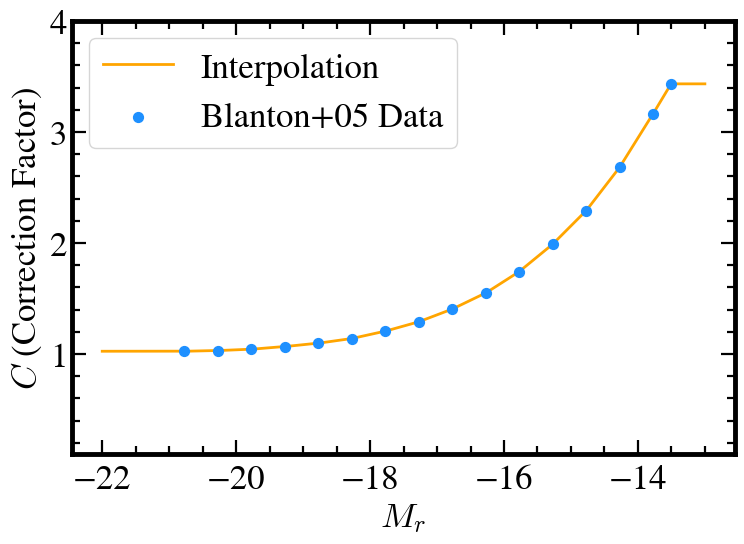

In [3]:
def C_sbcor(X):
    """
    Surface-brightness correction factor C(M_r) of Blanton et al. (2005),
    linearly interpolated in the table and clamped at both ends.
    """
    x = float(X)
    absmag = blanton['absmag']
    corr = blanton['CorrectionFactor']
    if x <= absmag.min():
        return corr.iloc[0]
    elif x >= absmag.max():
        return corr.iloc[-1]
    else:
        i_upper = np.searchsorted(absmag.values, x, side='right')
        i_lower = i_upper - 1
        x0, y0 = absmag.iloc[i_lower], corr.iloc[i_lower]
        x1, y1 = absmag.iloc[i_upper], corr.iloc[i_upper]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

# Show the interpolated curve against the table values
x_vals = np.linspace(-22, -13, 500)
y_vals = [C_sbcor(x) for x in x_vals]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_vals, y_vals, color='orange', label='Interpolation')
ax.scatter(blanton['absmag'], blanton['CorrectionFactor'], color='dodgerblue', s=50, zorder=10, label='Blanton+05 Data')
ax.set_xlabel(r'$M_r$')
ax.set_ylabel(r'$C$ (Correction Factor)')
ax.set_ylim([0.1, 4])
ax.legend()
plt.tight_layout()
plt.show()

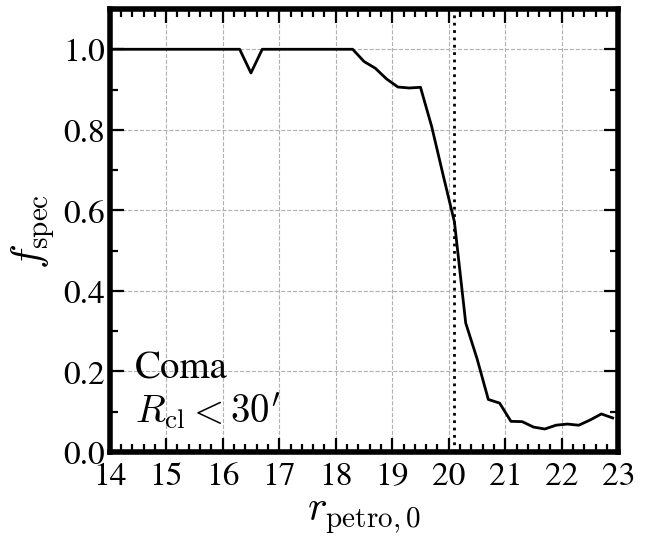

Cluster Coma (Rcl_arcmin < 30):
  Cumulative f_spec > 0.90 at r_petro = 19.70
  Value f_spec > 0.50 at r_petro = 20.10


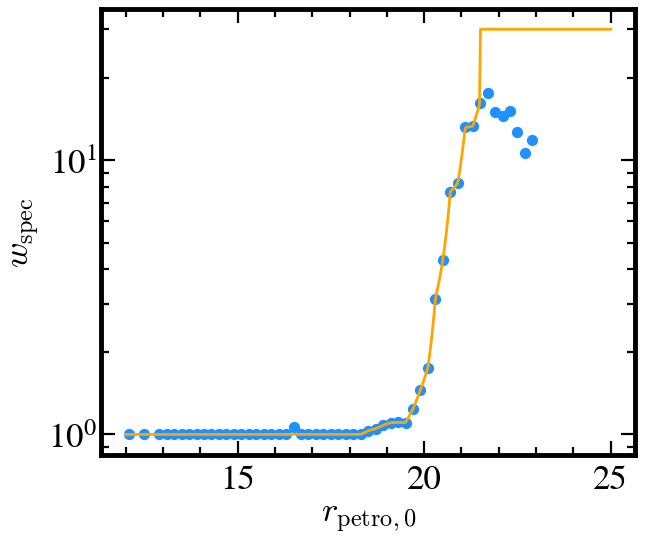

In [4]:
# ============================================================================
# Spectroscopic completeness f_spec(r) and the weight w_spec = 1 / f_spec
# ============================================================================

# Absolute magnitude of the spectroscopic completeness limit (r = 20.8)
d_lum = cosmo.luminosity_distance(Z_CLID).to('pc').value
DM = 5 * np.log10(d_lum) - 5
spec_comp_limit = 20.8 - DM

cluster_id = "Coma"

# Galaxies within 30 arcmin
cluster_data = df[(df['p_radgal'] < 30) & (df['p_probpsf'] == 0)].copy()
cluster_data['p_petromag_r_0'] = cluster_data['p_petromag_r'] - cluster_data['p_extinction_r']

# 0.2-mag bins
bin_width = 0.2
bin_edges = np.arange(12, 23 + bin_width, bin_width)
bins = pd.cut(cluster_data['p_petromag_r_0'], bins=bin_edges, include_lowest=False)

# Per bin: all galaxies and galaxies with a redshift
grouped = cluster_data.groupby(bins, observed=False)
total_counts = grouped.size()
valid_z_counts = grouped.apply(lambda x: (x['z_tot_z'] != -9.0).sum())

bin_centers = [round(interval.mid, 2) for interval in bins.cat.categories]

# f_spec per bin and cumulative
ratios = (valid_z_counts / total_counts).fillna(0)
ratios.index = bin_centers

cumulative_valid = valid_z_counts.cumsum()
cumulative_total = total_counts.cumsum()
cumulative_ratios = (cumulative_valid / cumulative_total).fillna(0)
cumulative_ratios.index = bin_centers

# Faintest bins with cumulative f_spec > 0.9 and per-bin f_spec > 0.5
bin_cum90 = next((x for x in reversed(bin_centers) if cumulative_ratios.get(x, 0) > 0.90), None)
bin_val50 = next((x for x in reversed(bin_centers) if ratios.get(x, 0) > 0.50), None)

# ---- f_spec plot ----
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(ratios.index, ratios, '-', color='black', lw=2)
ax.set_xlim(14, 23)
ax.set_xticks(np.arange(14, 23, 1))
ax.set_ylim([0, 1.1])
ax.xaxis.set_minor_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.grid(which='major', axis='both', linestyle='--', linewidth=0.8)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.set_ylabel(r'$f_\mathrm{spec}$', fontsize=30)
ax.set_xlabel(r'$r_{\mathrm{petro,0}}$', fontsize=30)
ax.tick_params(which='both', top=True, right=True, labelsize=24)

if bin_val50 is not None:
    ax.axvline(x=bin_val50, color='black', linestyle=':', linewidth=2, label=r'$f_\mathrm{spec} > 0.5$')

ax.text(0.05, 0.15, cluster_id, transform=ax.transAxes, fontsize=28, ha='left', va='bottom')
ax.text(0.05, 0.05, r'$R_\mathrm{cl}<30^\prime$', transform=ax.transAxes, fontsize=28, ha='left', va='bottom')
for spine in ax.spines.values():
    spine.set_linewidth(4)

plt.tight_layout()
plt.show()

print(f"Cluster {cluster_id} (Rcl_arcmin < 30):")
if bin_cum90 is not None:
    print(f"  Cumulative f_spec > 0.90 at r_petro = {bin_cum90:.2f}")
if bin_val50 is not None:
    print(f"  Value f_spec > 0.50 at r_petro = {bin_val50:.2f}")

# ---- f_spec table and the weight function ----
f_spec_df = pd.DataFrame({
    'p_petromag_r_0': ratios.index,
    'total_galaxies': total_counts.values,
    'valid_redshifts': valid_z_counts.values,
    'f_spec': ratios.values
}).sort_values(by='p_petromag_r_0').reset_index(drop=True)

def w_spec(X):
    """
    Spectroscopic completeness weight 1 / f_spec at apparent magnitude X,
    linearly interpolated between bin centres. Weight is 1 for X <= 17
    (complete) and capped at 30 for X >= 21.5.
    """
    X = float(X)
    if X <= 17:
        return 1.0
    if X >= 21.5:
        return 30.0
    lower = f_spec_df[f_spec_df['p_petromag_r_0'] <= X].iloc[-1]
    upper = f_spec_df[f_spec_df['p_petromag_r_0'] > X].iloc[0]
    x0, y0 = lower['p_petromag_r_0'], lower['f_spec']
    x1, y1 = upper['p_petromag_r_0'], upper['f_spec']
    interp = y0 + (y1 - y0) * (X - x0) / (x1 - x0)
    return 1.0 / interp

x_vals = np.linspace(12, 25, 500)
y_vals = [w_spec(x) for x in x_vals]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(x_vals, y_vals, color='orange')
ax.scatter(f_spec_df['p_petromag_r_0'], 1 / f_spec_df['f_spec'], color='dodgerblue', s=50)
ax.set_xlabel(r'$r_\mathrm{petro, 0}$')
ax.set_ylabel(r'$w_\mathrm{spec}$')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Luminosity function of Coma

Raw and corrected number counts per 0.5-mag bin of the members within 30′, then a Schechter fit by MCMC to the corrected counts brighter than the spectroscopic completeness limit (see notebook 02 for details).

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_14657/3003090199.py:21: RuntimeWarning: invalid value encountered in sqrt
  yerr_raw_lower = np.sqrt(hist_raw - 0.25)


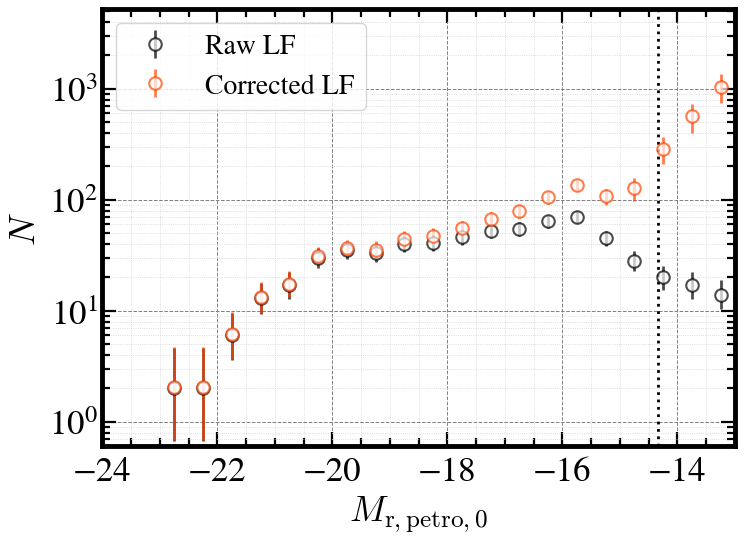

In [5]:
# Members within 30 arcmin (galaxies by the SDSS star/galaxy separator)
df_plot = df[
    (df['p_radgal'] < 30) &
    (df['p_probpsf'] == 0) &
    (df['member'] == 1)
].copy()

# Weight = surface-brightness correction x spectroscopic-completeness correction
df_plot['C_sbcor'] = df_plot['p_petromag_r_absmag'].apply(C_sbcor)
df_plot['w_spec'] = df_plot['p_petromag_r_0'].apply(w_spec)
df_plot['weight'] = df_plot['C_sbcor'] * df_plot['w_spec']

# 0.5-mag bins in M_r
bin_width = 0.5
bin_edges = np.arange(-24, -12 + bin_width, bin_width)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Raw counts and Gehrels (1986) errors
hist_raw, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges)
yerr_raw_upper = np.sqrt(hist_raw + 0.75) + 1
yerr_raw_lower = np.sqrt(hist_raw - 0.25)

# Weighted counts; variance = sum of squared weights
hist_weighted, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges, weights=df_plot['weight'])
var_weighted, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges, weights=(df_plot['weight'] ** 2))
yerr_weighted_upper = np.sqrt(var_weighted + 0.75) + 1
yerr_weighted_lower = np.sqrt(np.maximum(var_weighted - 0.25, 0))

# ---- Raw vs. corrected counts ----
fig, ax = plt.subplots(figsize=(8, 6))

mask_raw = hist_raw > 0
ax.errorbar(
    bin_centers[mask_raw], hist_raw[mask_raw],
    yerr=[yerr_raw_lower[mask_raw], yerr_raw_upper[mask_raw]],
    fmt='o', color='black', ecolor='black',
    markerfacecolor='white', markeredgewidth=1.5, capsize=0,
    label='Raw LF', alpha=0.7, markersize=9
)

mask_corr = hist_weighted > 0
ax.errorbar(
    bin_centers[mask_corr], hist_weighted[mask_corr],
    yerr=[yerr_weighted_lower[mask_corr], yerr_weighted_upper[mask_corr]],
    fmt='o', color='orangered', ecolor='orangered',
    markerfacecolor='white', markeredgewidth=1.5, capsize=0,
    label='Corrected LF', alpha=0.7, markersize=9
)

ax.set_yscale('log')
ax.set_xlim(-24, -13)
ax.set_ylim([0.6, 5 * max(hist_raw.max(), hist_weighted.max())])
ax.set_xlabel(r'$M_\mathrm{r,petro,0}$', fontsize=26)
ax.set_ylabel(r'$N$', fontsize=26)
ax.grid(True, which='major', color='gray', linestyle='--', linewidth=0.7)
ax.grid(True, which='minor', color='lightgray', linestyle=':', linewidth=0.6)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.legend(fontsize=20, loc='upper left')

# Completeness limit r = 20.7 in absolute magnitude
ax.axvline(20.7 - DM, color='black', linestyle=':', linewidth=2)

plt.tight_layout()
plt.show()

In [6]:
import emcee

# ============================================================================
# MCMC Schechter fit to the corrected counts per bin
# ============================================================================
# The model density is converted to counts (x bin width x volume) so that the
# Gaussian likelihood is evaluated on the same quantity as the data.

def schechter_1D_LF(M, phi_0, M_star, alpha):
    exponent = 10 ** (0.4 * (M_star - M))
    return phi_0 * exponent ** (1 + alpha) * np.exp(-exponent)

def log_likelihood(theta, M, y, yerr):
    phi_0, M_star, alpha = theta
    model_density = schechter_1D_LF(M, phi_0, M_star, alpha)
    model_counts = model_density * bin_width * volume_h3
    sigma2 = yerr ** 2
    return -0.5 * np.sum((y - model_counts) ** 2 / sigma2 + np.log(2 * np.pi * sigma2))

def log_prior(theta):
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 100 and -24 < M_star < -14 and -3 < alpha < 0:     # flat priors
        return 0.0
    return -np.inf

def log_probability(theta, M, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, M, y, yerr)

# Volume (same as above)
h = cosmo.H0.value / 100.0
z = Z_CLID
comoving_distance = cosmo.comoving_distance(z)
theta = 30 * u.arcmin
transverse_comoving_distance = comoving_distance * (theta.to(u.radian) / u.radian)
comoving_volume = 3 * np.pi * transverse_comoving_distance**3
volume_h3 = comoving_volume.value * h**3

# Bins
bin_width = 0.5
bin_edges = np.arange(-24, -12 + bin_width, bin_width)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Raw and corrected counts
weights = df_plot['weight']
hist_raw, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges)
hist_corr, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges, weights=weights)
weight_squared = df_plot['weight'] ** 2
variance_corr, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges, weights=weight_squared)

# Error bars: Gehrels (1986) for the plot, sqrt(variance) for the fit
yerr_upper_raw = np.sqrt(hist_raw + 0.75) + 1
yerr_lower_raw = np.sqrt(hist_raw - 0.25)
yerr_upper_corr = np.sqrt(variance_corr + 0.75) + 1
yerr_lower_corr = np.sqrt(np.maximum(variance_corr - 0.25, 0))
yerr_corr = np.sqrt(variance_corr)

# Fit range: brighter than the spectroscopic completeness limit
fit_range = (-24, spec_comp_limit)
mask_fit = (bin_centers > fit_range[0]) & (bin_centers < fit_range[1]) & (hist_corr > 0)
x_fit = bin_centers[mask_fit]
y_fit = hist_corr[mask_fit]
yerr_fit = yerr_corr[mask_fit]

initial = np.array([10, -21.35, -1.24])        # phi_0, M*, alpha
nwalkers, ndim = 42, initial.size
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x_fit, y_fit, yerr_fit))
sampler.run_mcmc(pos, 5000, progress=True)

# Medians and 16-84 percentile errors
samples = sampler.get_chain(discard=1000, thin=15, flat=True)
phi0_lo, phi0_med, phi0_hi = np.percentile(samples[:, 0], [16, 50, 84])
mstar_lo, mstar_med, mstar_hi = np.percentile(samples[:, 1], [16, 50, 84])
alpha_lo, alpha_med, alpha_hi = np.percentile(samples[:, 2], [16, 50, 84])
phi0_err = [phi0_med - phi0_lo, phi0_hi - phi0_med]
M_star_err = [mstar_med - mstar_lo, mstar_hi - mstar_med]
alpha_err = [alpha_med - alpha_lo, alpha_hi - alpha_med]

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_14657/1099791449.py:55: RuntimeWarning: invalid value encountered in sqrt
  yerr_lower_raw = np.sqrt(hist_raw - 0.25)


  0%|          | 0/5000 [00:00<?, ?it/s]

  3%|▎         | 140/5000 [00:00<00:03, 1390.93it/s]

  6%|▌         | 282/5000 [00:00<00:03, 1403.48it/s]

  8%|▊         | 425/5000 [00:00<00:03, 1410.97it/s]

...

 91%|█████████ | 4560/5000 [00:03<00:00, 1413.22it/s]

 94%|█████████▍| 4704/5000 [00:03<00:00, 1419.38it/s]

 97%|█████████▋| 4848/5000 [00:03<00:00, 1423.49it/s]

100%|█████████▉| 4992/5000 [00:03<00:00, 1428.24it/s]

100%|██████████| 5000/5000 [00:03<00:00, 1415.28it/s]

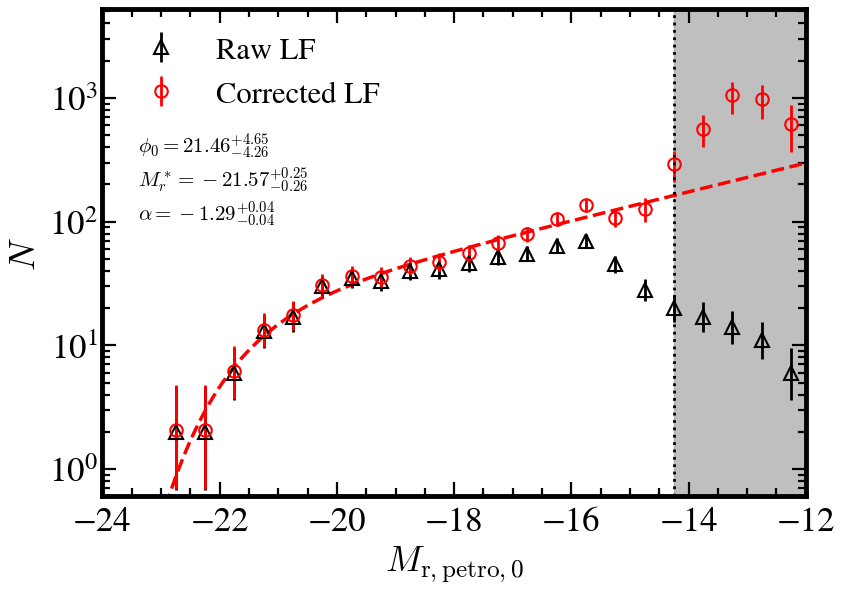

In [7]:
# ============================================================================
# Figure: raw and corrected LF with the MCMC Schechter fit
# ============================================================================
fig, ax = plt.subplots(figsize=(9, 6.5))

# Raw counts
mask_raw = hist_raw > 0
ax.errorbar(bin_centers[mask_raw], hist_raw[mask_raw],
            yerr=[yerr_lower_raw[mask_raw], yerr_upper_raw[mask_raw]],
            fmt='^', color='black', ecolor='black',
            markerfacecolor='none', markeredgewidth=1.5, capsize=0,
            label='Raw LF', alpha=1.0, markersize=10)

# Corrected counts (fitted)
mask_corr = hist_corr > 0
ax.errorbar(bin_centers[mask_corr], hist_corr[mask_corr],
            yerr=[yerr_lower_corr[mask_corr], yerr_upper_corr[mask_corr]],
            fmt='o', color='red', ecolor='red',
            markerfacecolor='none', markeredgewidth=1.5, capsize=0,
            label='Corrected LF', alpha=1.0, markersize=9, zorder=2)

# Best-fit model, converted from density to counts
x_model = np.linspace(-24, -12, 1000)
y_model_density = schechter_1D_LF(x_model, phi0_med, mstar_med, alpha_med)
y_model = y_model_density * bin_width * volume_h3
ax.plot(x_model, y_model, color='red', linestyle='--', lw=2.5)

ax.set_yscale('log')
ax.set_xlim(-24, -12)
ax.set_ylim([0.6, max(hist_raw.max(), hist_corr.max()) * 5])
ax.set_xlabel(r'$M_\mathrm{r,petro,0}$', fontsize=26)
ax.set_ylabel(r'$N$', fontsize=26)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.legend(fontsize=22, loc='upper left', frameon=False)

# Region fainter than the spectroscopic completeness limit
ax.axvline(spec_comp_limit, color='black', linestyle=':', linewidth=2)
ax.axvspan(spec_comp_limit, -12, color='gray', alpha=0.5)

annotation_text = (
    r"$\phi_0 = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(phi0_med, phi0_err[1], phi0_err[0]) + "\n" +
    r"$M^*_r = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(mstar_med, M_star_err[1], M_star_err[0]) + "\n" +
    r"$\alpha = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(alpha_med, alpha_err[1], alpha_err[0])
)
ax.text(0.05, 0.75, annotation_text, transform=ax.transAxes,
        fontsize=15, verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none', alpha=0.8))

plt.tight_layout()
# plt.savefig('../../FIGURE/images/Coma_LF.pdf', bbox_inches='tight', dpi=1000)
plt.show()